# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 2: Baysian Linear Regression part I

Topics covered 
 - Working with Pandas data frames
 - Working with 'for' loops in Python
 - Fitting linear regression models
 - Polynomial curve fitting
 - Introduction to training and test error concepts
 - Ridge and Lasso regression
 

We begin with loading the necessary libraries. We will use **numpy** and **matplotlib** that we saw on week 1 and gain familiarity with **pandas** for handling data. We will also get started on **sklearn** for linear and ridge regression, spliting data into train and test samples and get our hands on a real dataset on Boston house prices

In [1]:
import numpy as np             
import pandas as pd           #Python Data Analysis Library handle data in a user friendly way
#import random
import matplotlib.pyplot as plt #for plots
%matplotlib inline
from sklearn import linear_model # A very popular Python library for Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split #needed to for assessing prediction
from sklearn import datasets ## imports datasets from scikit-learn

### Linear Regression / Polynomial Curve fitting

We start with the polynomial curve fitting exercise seen in the lecture slides. The *truth* is the functions $sin(2\pi x)$ for $x \in [0,1]$. We observe 10 points, equispaced in $[0,1]$ - array x,  with $N(0,0.3^2)$ independent measurement error, array y. The array xg contains a grid of 100 points in $[0,1]$

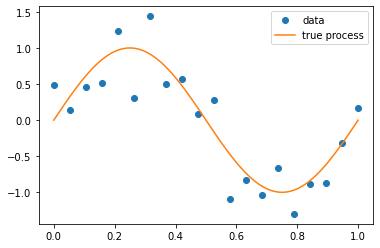

In [7]:
#Polynomial fitting exercise
np.random.seed(1)
x = np.linspace(0, 1, 20)
xg = np.linspace(0,1,100)
f = np.sin(2*np.pi*xg)
y = np.sin(2*np.pi*x)+0.3*np.random.randn(20)
plt.plot(x,y,'o',label='data')
plt.plot(xg,f,label='true process')
plt.legend()

In order to start working with pandas data frames we put x and y in pandas data frame called 'data'.

In [8]:
#put x,y into the pandas dataframe called data 
data = pd.DataFrame(np.column_stack([y,x]),columns=['y','x']) #columns, then column names
data

,y,x
0,0.487304,0.000000
1,0.141173,0.052632
2,0.455761,0.105263
3,0.515276,0.157895
4,1.229023,0.210526
5,0.306123,0.263158
6,1.439217,0.315789
7,0.507362,0.368421
8,0.571659,0.421053
9,0.089783,0.473684


We can add the variable 'x2' containing the values of x$^2$

In [9]:
data['x2']=data['x']**2
data

,y,x,x2
0,0.487304,0.000000,0.000000
1,0.141173,0.052632,0.002770
2,0.455761,0.105263,0.011080
3,0.515276,0.157895,0.024931
4,1.229023,0.210526,0.044321
5,0.306123,0.263158,0.069252
6,1.439217,0.315789,0.099723
7,0.507362,0.368421,0.135734
8,0.571659,0.421053,0.177285
9,0.089783,0.473684,0.224377


We need to also add the variable x$^3$ to x$^9$ so that we fit polynomials up to the 9-th degree. This can be done very quickly using a 'for loop'. See below how to use a 'for loop' in an example were string and numerical variables are being used.

In [10]:
#Expand the data including powers of x up to 9
for i in range(3,10):  #executes the following indented commands for i varying from 3 to 9
    colname = 'x%d'%i # the %d %i puts a different number in the name of each variable
    data[colname] = data['x']**i #raise to the power of i
    # the for loop continues until the first time a command is not indented.
data

,y,x,x2,x3,x4,x5,x6,x7,x8,x9
0,0.487304,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.141173,0.052632,0.002770,0.000146,0.000008,4.038611e-07,2.125585e-08,1.118729e-09,5.888046e-11,3.098972e-12
2,0.455761,0.105263,0.011080,0.001166,0.000123,1.292355e-05,1.360374e-06,1.431973e-07,1.507340e-08,1.586673e-09
3,0.515276,0.157895,0.024931,0.003936,0.000622,9.813824e-05,1.549551e-05,2.446660e-06,3.863147e-07,6.099706e-08
4,1.229023,0.210526,0.044321,0.009331,0.001964,4.135537e-04,8.706395e-05,1.832925e-05,3.858790e-06,8.123768e-07
5,0.306123,0.263158,0.069252,0.018224,0.004796,1.262066e-03,3.321226e-04,8.740068e-05,2.300018e-05,6.052679e-06
6,1.439217,0.315789,0.099723,0.031491,0.009945,3.140424e-03,9.917127e-04,3.131724e-04,9.889656e-05,3.123049e-05
7,0.507362,0.368421,0.135734,0.050007,0.018424,6.787693e-03,2.500729e-03,9.213212e-04,3.394341e-04,1.250547e-04
8,0.571659,0.421053,0.177285,0.074646,0.031430,1.323372e-02,5.572092e-03,2.346144e-03,9.878502e-04,4.159369e-04
9,0.089783,0.473684,0.224377,0.106284,0.050345,2.384759e-02,1.129623e-02,5.350845e-03,2.534611e-03,1.200605e-03


Now we will fit a linear regression model with x and x$^2$, in other words a polynomial of the 2nd degree. The sklearn command 'Linear Regression' is not particularly user friendly in terms of its output so we will summarise the results in a pandas data frame. We will look at the **training mean squared error, which is the average squared distance between the predicted y's from the model and the actual y's**. We will also look at the regression coefficients  

In [11]:
predictors = ['x','x2']
linreg = LinearRegression()

        MSE  intercept        x        x2
0  0.329906   0.885165 -2.23262  0.558704


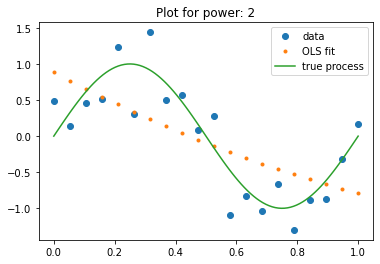

In [12]:
predictors = ['x','x2']
linreg = LinearRegression()
linreg.fit(data[predictors],data['y'])
y_pred = linreg.predict(data[predictors])

#code for plot
plt.plot(data['x'],data['y'],'o',label='data')
plt.plot(data['x'],y_pred, '.', label='OLS fit')
plt.plot(xg,f,label='true process')
plt.title('Plot for power: 2')
plt.legend()

#output to return
mse = np.mean((y_pred-data['y'])**2)
results = [mse]
results.extend([linreg.intercept_])
results.extend(linreg.coef_) 
results = pd.DataFrame([results],columns = ['MSE','intercept','x','x2'])
print(results)

### Activity 1

Fit polynomials of 3rd and 9th degrees to the previous data and provide their coefficients and their training mean squared error. 

#### Answer 

Put yout code below

In [17]:
def predict(predictors):    
    linreg = LinearRegression()
    linreg.fit(data[predictors],data['y'])
    y_pred = linreg.predict(data[predictors])

    #code for plot
    plt.plot(data['x'],data['y'],'o',label='data')
    plt.plot(data['x'],y_pred, '.', label='OLS fit')
    plt.plot(xg,f,label='true process')
    plt.title('Plot for power: 2')
    plt.legend()

    #output to return
    mse = np.mean((y_pred-data['y'])**2)
    results = [mse]
    results.extend([linreg.intercept_])
    results.extend(linreg.coef_) 
    results = pd.DataFrame([results],columns = ['MSE','intercept']+predictors)
    print(results)

        MSE  intercept          x          x2           x3            x4  \
0  0.081848   0.494404 -28.166157  623.035175 -5468.346267  25969.850526   

             x5             x6             x7           x8            x9  
0 -72426.815549  120870.405564 -118380.613726  62679.51778 -13839.184443  


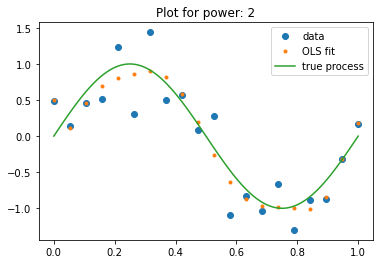

In [25]:
predict(['x','x2','x3','x4','x5','x6','x7','x8','x9'])

### Fit visualisation

We will now introduce a more dense version of x and its powers (based on the array xg) in order to compare the model fit with the true process in the entire interval of $[0,1]$.

In [26]:
xg0 = np.ones(100)
grid = pd.DataFrame(np.column_stack([xg0,xg]),columns=['x0','x'])
for i in range(2,10):  
    colname = 'x%d'%i 
    grid[colname] = grid['x']**i 
grid.head()

,x0,x,x2,x3,x4,x5,x6,x7,x8,x9
0,1.0,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,1.0,0.010101,0.000102,0.000001,1.041020e-08,1.051536e-10,1.062157e-12,1.072886e-14,1.083723e-16,1.094670e-18
2,1.0,0.020202,0.000408,0.000008,1.665633e-07,3.364914e-09,6.797807e-11,1.373294e-12,2.774332e-14,5.604711e-16
3,1.0,0.030303,0.000918,0.000028,8.432265e-07,2.555232e-08,7.743127e-10,2.346402e-11,7.110309e-13,2.154639e-14
4,1.0,0.040404,0.001632,0.000066,2.665012e-06,1.076773e-07,4.350596e-09,1.757817e-10,7.102290e-12,2.869612e-13


The following code, in addition to fitting the polynomial on the data, also provides the fit that correspond to it in the entire interval $[0,1]$.

Below we see the case for a 9-th degree polynomial but you can repeat for eny order between 1 and 9 by setting 'npower' to the desired order.

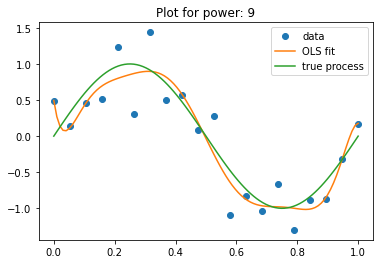

In [27]:
npower=9
grid_predictors = ['x0','x']
grid_predictors.extend(['x%d'%i for i in range(2,npower+1)])
X = grid[grid_predictors]
predictors = ['x']
predictors.extend(['x%d'%i for i in range(2,npower+1)])
linreg = LinearRegression()
linreg.fit(data[predictors],data['y'])
beta = [linreg.intercept_]
beta.extend(linreg.coef_)
fitted = np.dot(X,beta)

plt.plot(data['x'],data['y'],'o',label='data')
plt.plot(grid['x'],fitted, label='OLS fit')
plt.plot(xg,f,label='true process')
plt.title('Plot for power: %d'%npower)
plt.legend()

## Ridge and Lasso Regression

We now turn to Ridge regression. We will use all powers of x up to 9 but we also include a penalty term on the squared value of the coefficients. The amount penalisation is controlled by the parameter 'lam'.

Below is some code that fits a Ridge regression model (for Lasso just change 'Ridge' with 'Lasso') and provides (as before) the estimates of the coefficients and the training MSE.

,MSE,intercept,x1,x2,x3,x4,x5,x6,x7,x8,x9
0,0.104374,0.192947,4.915986,-7.466172,-8.961156,0.582199,6.51162,6.932191,3.79468,-0.813757,-5.509631


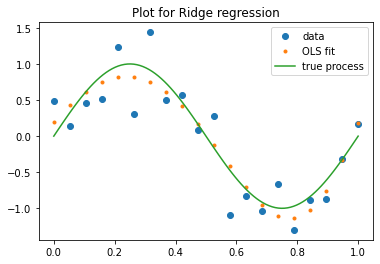

In [28]:
npower = 9
predictors = ['x']
predictors.extend(['x%d'%i for i in range(2,npower+1)])
lam=np.exp(-8)
ridgereg = Ridge(alpha=lam)
ridgereg.fit(data[predictors],data['y'])
y_pred = ridgereg.predict(data[predictors])

#plot
plt.plot(data['x'],data['y'],'o',label='data')
plt.plot(data['x'],y_pred,'.', label='OLS fit')
plt.plot(xg,f,label='true process')
plt.title('Plot for Ridge regression')
plt.legend()

#output to return
mse = np.mean((y_pred-data['y'])**2)
results = [mse]
results.extend([ridgereg.intercept_])
results.extend(ridgereg.coef_)
col = ['MSE','intercept'] + ['x%d'%i for i in range(1,npower+1)]
results = pd.DataFrame([results],columns = col)
results

c:\Users\19175\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.031231400408615162, tolerance: 0.0011801740205338426
  model = cd_fast.enet_coordinate_descent(


,MSE,intercept,x1,x2,x3,x4,x5,x6,x7,x8,x9
0,0.119579,0.192947,4.915986,-7.466172,-8.961156,0.582199,6.51162,6.932191,3.79468,-0.813757,-5.509631


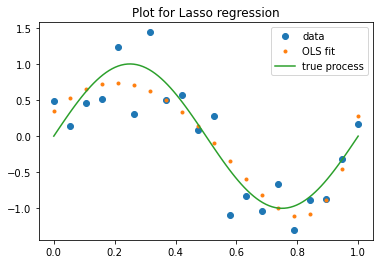

In [29]:
npower = 9
predictors = ['x']
predictors.extend(['x%d'%i for i in range(2,npower+1)])
lam=np.exp(-7)
lassoreg = Lasso(alpha=lam)
lassoreg.fit(data[predictors],data['y'])
y_pred = lassoreg.predict(data[predictors])

#plot
plt.plot(data['x'],data['y'],'o',label='data')
plt.plot(data['x'],y_pred,'.', label='OLS fit')
plt.plot(xg,f,label='true process')
plt.title('Plot for Lasso regression')
plt.legend()

#output to return
mse = np.mean((y_pred-data['y'])**2)
results = [mse]
results.extend([ridgereg.intercept_])
results.extend(ridgereg.coef_)
col = ['MSE','intercept'] + ['x%d'%i for i in range(1,npower+1)]
results = pd.DataFrame([results],columns = col)
results

### Test Error - Out of sample performance

In the previous exercise we compared visually the fit from the model when applied to x being in the interval $[0,1]$ versus the true function. This is very useful but cannot be done in practice as the true function is unknown.

We will therefore repeat the exercise under a more realistic setting: 
- Generate more 100 noisly observations from the function $sin(2\pi x)$ as before
- **Randomly select 10** of those. These will form the **train sample** that will be used to fit the models and obtain the regression coefficients. 
- Set **aside** the remaining 90 observations. These will for the **test sample** that will be used to assess the predictions of each model that was estimated in the train sample. 
- Contrasting those predictions to the real data will allow us to estimate the **test error** and assess the out of sample performance of each model.
- Monitor both the training and test errors for each model.


We start by simulate 100 noisy data

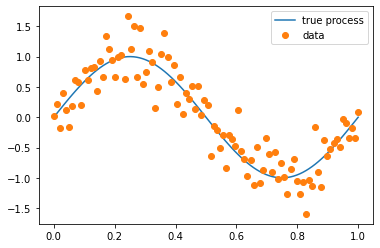

In [30]:
#Simulate more data
np.random.seed(4)
x = np.linspace(0,1,100)
f = np.sin(2*np.pi*x)
y = np.sin(2*np.pi*x)+0.3*np.random.randn(100)
plt.plot(x,f,label='true process')
plt.plot(x,y,'o',label='data')
plt.legend()

In [31]:
data = pd.DataFrame(np.column_stack([y,x]),columns=['y','x']) #columns, then column names
npower = 9
for i in range(2,10):  
    colname = 'x%d'%i 
    data[colname] = data['x']**i 
data.head()

,y,x,x2,x3,x4,x5,x6,x7,x8,x9
0,0.015169,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.213409,0.010101,0.000102,0.000001,1.041020e-08,1.051536e-10,1.062157e-12,1.072886e-14,1.083723e-16,1.094670e-18
2,-0.172180,0.020202,0.000408,0.000008,1.665633e-07,3.364914e-09,6.797807e-11,1.373294e-12,2.774332e-14,5.604711e-16
3,0.397331,0.030303,0.000918,0.000028,8.432265e-07,2.555232e-08,7.743127e-10,2.346402e-11,7.110309e-13,2.154639e-14
4,0.125658,0.040404,0.001632,0.000066,2.665012e-06,1.076773e-07,4.350596e-09,1.757817e-10,7.102290e-12,2.869612e-13


Next, we randomly split the data to train and test samples and see those

In [32]:
npower = 9 #feel free to try different numbers for npower
predictors = ['x']
predictors.extend(['x%d'%i for i in range(2,npower+1)])

# Split up your data
trainX, testX, trainy, testy = train_test_split(data[predictors],data['y'],
                                                test_size=0.9, random_state=1)
trainX

,x,x2,x3,x4,x5,x6,x7,x8,x9
1,0.010101,0.000102,0.000001,1.041020e-08,1.051536e-10,1.062157e-12,1.072886e-14,1.083723e-16,1.094670e-18
16,0.161616,0.026120,0.004221,6.822431e-04,1.102615e-04,1.782004e-05,2.880007e-06,4.654556e-07,7.522516e-08
64,0.646465,0.417917,0.270168,1.746542e-01,1.129078e-01,7.299089e-02,4.718603e-02,3.050410e-02,1.971982e-02
79,0.797980,0.636772,0.508131,4.054783e-01,3.235635e-01,2.581971e-01,2.060361e-01,1.644126e-01,1.311980e-01
5,0.050505,0.002551,0.000129,6.506377e-06,3.286049e-07,1.659621e-08,8.381923e-10,4.233294e-11,2.138028e-12
75,0.757576,0.573921,0.434789,3.293853e-01,2.495344e-01,1.890412e-01,1.432130e-01,1.084947e-01,8.219296e-02
9,0.090909,0.008264,0.000751,6.830135e-05,6.209213e-06,5.644739e-07,5.131581e-08,4.665074e-09,4.240976e-10
72,0.727273,0.528926,0.384673,2.797623e-01,2.034635e-01,1.479735e-01,1.076171e-01,7.826695e-02,5.692142e-02
12,0.121212,0.014692,0.001781,2.158660e-04,2.616557e-05,3.171585e-06,3.844345e-07,4.659812e-08,5.648257e-09
37,0.373737,0.139680,0.052203,1.951040e-02,7.291765e-03,2.725205e-03,1.018511e-03,3.806556e-04,1.422652e-04


In [33]:
testX

,x,x2,x3,x4,x5,x6,x7,x8,x9
80,0.808081,0.652995,0.527672,0.426402,3.445672e-01,2.784382e-01,2.250005e-01,1.818186e-01,1.469241e-01
84,0.848485,0.719927,0.610847,0.518294,4.397648e-01,3.731338e-01,3.165983e-01,2.686289e-01,2.279276e-01
33,0.333333,0.111111,0.037037,0.012346,4.115226e-03,1.371742e-03,4.572474e-04,1.524158e-04,5.080526e-05
81,0.818182,0.669421,0.547708,0.448125,3.666478e-01,2.999846e-01,2.454419e-01,2.008161e-01,1.643041e-01
93,0.939394,0.882461,0.828978,0.778737,7.315412e-01,6.872053e-01,6.455565e-01,6.064319e-01,5.696784e-01
...,...,...,...,...,...,...,...,...,...
50,0.505051,0.255076,0.128826,0.065064,3.286049e-02,1.659621e-02,8.381923e-03,4.233294e-03,2.138028e-03
25,0.252525,0.063769,0.016103,0.004066,1.026890e-03,2.593157e-04,6.548377e-05,1.653631e-05,4.175835e-06
6,0.060606,0.003673,0.000223,0.000013,8.176742e-07,4.955601e-08,3.003395e-09,1.820239e-10,1.103175e-11
71,0.717172,0.514335,0.368867,0.264541,1.897212e-01,1.360626e-01,9.758028e-02,6.998182e-02,5.018898e-02


Next we will 
 1. fit the linear regression model based on a polynomial of order 'npower' 
 2. calculate the train error as before
 2. obtain its predictions for the test dataset
 3. compare the prediction of the previous step against the test data

In [34]:
# Step 1
npower = 3
for i in range(2,10):  
    colname = 'x%d'%i 
    data[colname] = data['x']**i 
predictors = ['x']
predictors.extend(['x%d'%i for i in range(2,npower+1)])
linreg = LinearRegression()
linreg.fit(trainX[predictors],trainy)

# Step 2
y_pred_train = linreg.predict(trainX[predictors])
train_mse = np.mean((y_pred_train-trainy)**2)

# Steps 3 and 4
y_pred_test = linreg.predict(testX[predictors])
test_mse = np.mean((y_pred_test-testy)**2)

# output to return
results = [train_mse,test_mse]
results.extend([linreg.intercept_])
results.extend(linreg.coef_)
col = ['trainMSE','testMSE','intercept'] + ['x%d'%i for i in range(1,npower+1)]
results = pd.DataFrame([results],columns = col)
results

,trainMSE,testMSE,intercept,x1,x2,x3
0,0.057024,0.314036,-0.231657,9.443428,-22.769785,12.006192


We repeat with Ridge regression

In [35]:
npower = 9
predictors = ['x']
predictors.extend(['x%d'%i for i in range(2,npower+1)])

#Step 1
lam=np.exp(-2.5)
ridgereg = Ridge(alpha=lam)
ridgereg.fit(trainX,trainy)

#Step 2
y_pred_train = ridgereg.predict(trainX)
train_mse = np.mean((y_pred_train-trainy)**2)

#Steps 3 and 4
y_pred_test = ridgereg.predict(testX)
test_mse = np.mean((y_pred_test-testy)**2)

#output to return
results = [train_mse,test_mse]
results.extend([ridgereg.intercept_])
results.extend(ridgereg.coef_)
col = ['trainMSE','testMSE','intercept'] + ['x%d'%i for i in range(1,npower+1)]
results = pd.DataFrame([results],columns = col)
results

,trainMSE,testMSE,intercept,x1,x2,x3,x4,x5,x6,x7,x8,x9
0,0.129775,0.970924,0.38332,0.305146,-0.896981,-0.967604,-0.762387,-0.544173,-0.371911,-0.24848,-0.163753,-0.106841


... and then repeat with Lasso regression

In [36]:
npower = 9
predictors = ['x']
predictors.extend(['x%d'%i for i in range(2,npower+1)])

#Step 1
lam=np.exp(-2.5)
lassoreg = Lasso(alpha=lam)
lassoreg.fit(trainX,trainy)

#Step 2
y_pred_train = lassoreg.predict(trainX)
train_mse = np.mean((y_pred_train-trainy)**2)

#Steps 3 and 4
y_pred_test = lassoreg.predict(testX)
test_mse = np.mean((y_pred_test-testy)**2)

#output to return
results = [train_mse,test_mse]
results.extend([lassoreg.intercept_])
results.extend(lassoreg.coef_)
col = ['trainMSE','testMSE','intercept'] + ['x%d'%i for i in range(1,npower+1)]
results = pd.DataFrame([results],columns = col)
results

,trainMSE,testMSE,intercept,x1,x2,x3,x4,x5,x6,x7,x8,x9
0,0.256198,0.38206,0.191929,-0.0,-1.079102,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


### Activity 2

1. Find the order of polynomial that produces the smallest test MSE. 
2. Can you beat that with Ridge or Lasso Regression? In other words can you find penalty 'lam' such that the Ridge or Lasso regression model produces an even smaller test MSE?

#### Answer

Put your code and asnwers below

In [ ]:
def predict(npower):
    predictors = ['x']
    predictors.extend(['x%d'%i for i in range(2,npower+1)])

    linreg = LinearRegression()
    linreg.fit(data[predictors],data['y'])
    y_pred = linreg.predict(data[predictors])

    #Step 1
    lam=np.exp(-2.5)
    lassoreg = Lasso(alpha=lam)
    lassoreg.fit(trainX,trainy)

    #Step 2
    y_pred_train = lassoreg.predict(trainX)
    train_mse = np.mean((y_pred_train-trainy)**2)

    #Steps 3 and 4
    y_pred_test = lassoreg.predict(testX)
    test_mse = np.mean((y_pred_test-testy)**2)

    #output to return
    results = [train_mse,test_mse]

    #output to return
    mse = np.mean((y_pred-data['y'])**2)
    results = [mse]
    return(results[0])

In [ ]:
min_index = 0
min_mse = 99999
for j in range(2,9):
    mse = predict(j)
    if mse < min_mse:
        min_mse = mse
        min_index = j
print(min_index)

0.283427092359438
0.08561741556819659
0.08561671047308753
0.08347405777203068
0.08303620207999637
0.08176037218630175
0.08121150701846633
8


### Real data example

Finally we will look at a real data example, some info on which is given below:

 - 442 diabetes patients
 - 10 main variables, x_1,...,x_{10} : age, gender, body mass index, average blood pressure (map), and six blood serum measurements (tc, ldl, hdl, tch, ltg, glu)
 - 45 interactions of the form xjxk
 - 9 quadratic effects of the form x_j^2 (gender is binary, so x^2=x_2^2)
 - measure of disease progression taken one year later, $y$

We have a total of $p=64$ variables that we might use to predict $y$. It seems plausible that a subset of the variables will reliably predict $y$

First we load the `diabetes.data.txt` file to get y

In [74]:
diabetesY = pd.read_csv('diabetes.data.txt',sep="\t")
diabetesY

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.00,157,93.2,38.0,4.00,4.8598,87,151
1,48,1,21.6,87.00,183,103.2,70.0,3.00,3.8918,69,75
2,72,2,30.5,93.00,156,93.6,41.0,4.00,4.6728,85,141
3,24,1,25.3,84.00,198,131.4,40.0,5.00,4.8903,89,206
4,50,1,23.0,101.00,192,125.4,52.0,4.00,4.2905,80,135
...,...,...,...,...,...,...,...,...,...,...,...
437,60,2,28.2,112.00,185,113.8,42.0,4.00,4.9836,93,178
438,47,2,24.9,75.00,225,166.0,42.0,5.00,4.4427,102,104
439,60,2,24.9,99.67,162,106.6,43.0,3.77,4.1271,95,132
440,36,1,30.0,95.00,201,125.2,42.0,4.79,5.1299,85,220


Extract the target variable $Y$ and standardise

In [75]:
Y = diabetesY['Y']
y = (Y - np.mean(Y))/np.std(Y)

Then we load the `data64.txt` file to get X, consisting of the 64 variables mentioned earlier

In [77]:
diabetesX = pd.read_csv('data64.txt', sep="\t")
X = diabetesX.values
X = (X - np.mean(X,axis=0))/np.std(X,axis=0)
feature_names = diabetesX.columns.values
print(feature_names)

['age' 'sex' 'bmi' 'map' 'tc' 'ldl' 'hdl' 'tch' 'ltg' 'glu' 'age^2'
 'bmi^2' 'map^2' 'tc^2' 'ldl^2' 'hdl^2' 'tch^2' 'ltg^2' 'glu^2' 'age:sex'
 'age:bmi' 'age:map' 'age:tc' 'age:ldl' 'age:hdl' 'age:tch' 'age:ltg'
 'age:glu' 'sex:bmi' 'sex:map' 'sex:tc' 'sex:ldl' 'sex:hdl' 'sex:tch'
 'sex:ltg' 'sex:glu' 'bmi:map' 'bmi:tc' 'bmi:ldl' 'bmi:hdl' 'bmi:tch'
 'bmi:ltg' 'bmi:glu' 'map:tc' 'map:ldl' 'map:hdl' 'map:tch' 'map:ltg'
 'map:glu' 'tc:ldl' 'tc:hdl' 'tc:tch' 'tc:ltg' 'tc:glu' 'ldl:hdl'
 'ldl:tch' 'ldl:ltg' 'ldl:glu' 'hdl:tch' 'hdl:ltg' 'hdl:glu' 'tch:ltg'
 'tch:glu' 'ltg:glu']


Split the data into train and test datasets.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100/442, random_state=5)

A function to illustrate the coefficients

In [79]:
def plot_coefficients(coefficients, num_features=64):
    plt.figure(figsize=(15,4))
    plt.bar(range(num_features), np.abs(coefficients))
    plt.xticks(range(num_features),feature_names[:num_features],rotation=-45)
    plt.xlabel('Coefficient')
    plt.ylabel('Absolute value - log scale')
    plt.yscale('log')

Fit and calculate the test error of the linear regression model

Linear Regression MSE:  0.5751053849626849


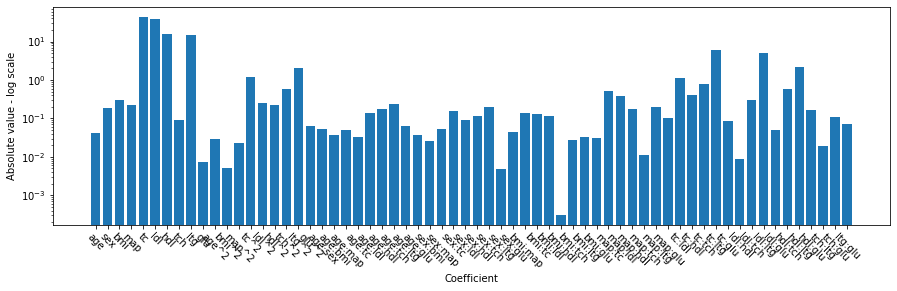

In [80]:
linreg = LinearRegression()
linreg.fit(X_train,y_train)
y_pred = linreg.predict(X_test)
print('Linear Regression MSE: ',np.mean((y_test - y_pred)**2))
plot_coefficients(linreg.coef_)

### Activity 3

Fit and calculate the test error of the ridge and lasso regression models. Try to find an optimal lambda for them

#### Answer 

Put your code below

Ridge Regression MSE:  0.5500941690295564


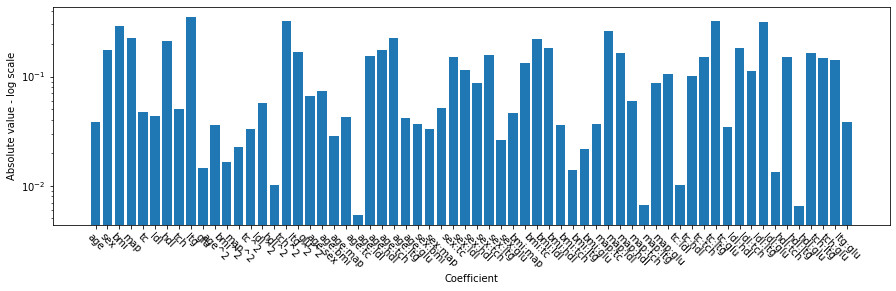

In [ ]:
lam = 1

linreg = Ridge(lam)
linreg.fit(X_train,y_train)
y_pred = linreg.predict(X_test)
print('Ridge Regression MSE: ',np.mean((y_test - y_pred)**2))
plot_coefficients(linreg.coef_)

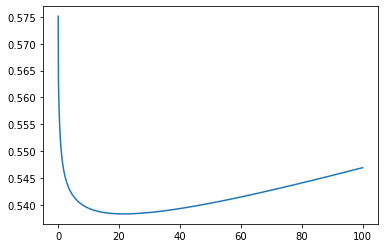

In [ ]:
mses = list()
vals = np.linspace(0,100,num=1000)
for i in vals:
    lam = i
    linreg = Ridge(lam)
    linreg.fit(X_train,y_train)
    y_pred = linreg.predict(X_test)
    mse = np.mean((y_test - y_pred)**2)
    mses.append(mse)

plt.plot(vals, mses)

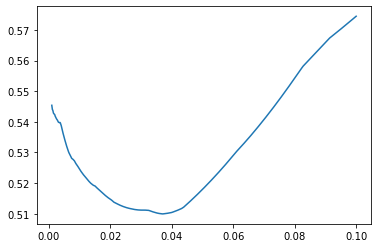

In [89]:
mses = list()
vals = np.linspace(0.001,0.1,num=1000)
for i in vals:
    lam = i
    linreg = Lasso(lam)
    linreg.fit(X_train,y_train)
    y_pred = linreg.predict(X_test)
    mse = np.mean((y_test - y_pred)**2)
    mses.append(mse)

plt.plot(vals, mses)